In [1]:
import torch
import numpy as np

import os
import sys
import statistics

sys.path.append(os.path.abspath(".."))

from models.vae_adain import Model as VAE
from default_config import cfg as cfg_original
from default_config import cfg as cfg_mirroerd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Using /home/ncaytuir/.cache/torch_extensions/py38_cu111 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/ncaytuir/.cache/torch_extensions/py38_cu111/emd_ext/build.ninja...
Building extension module emd_ext...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)
ninja: no work to do.
Loading extension module emd_ext...
load emd_ext time: 0.212s
utils/utils.py: USE_COMET=1, USE_WB=0


In [2]:
# Path to ckpt
ckpt_path_original = "/home/ncaytuir/LION_necs/lion_ckpt/unconditional/airplane/checkpoints/vae_only.pt"
cfg_path_original = "/home/ncaytuir/LION_necs/lion_ckpt/unconditional/airplane/cfg.yml"

ckpt_path_mirrored = "/home/ncaytuir/exp/0319/airplane/5270ech_hvae_lion_B32/checkpoints/epoch_7999_iters_351999.pt"
cfg_path_mirrored = "/home/ncaytuir/exp/0319/airplane/5270ech_hvae_lion_B32/cfg.yml"

input_original_dir = "/home/ncaytuir/data/Datasets/ShapeNetCore.v2.PC15k/02691156/val"
input_mirrored_dir = "/home/ncaytuir/data/Datasets/Mirrored_ShapeNetCore.v2.PC15k/02691156/val"

shape1 = "/home/ncaytuir/data/Datasets/ShapeNetCore.v2.PC15k/02691156/val/1a54a2319e87bd4071d03b466c72ce41.npy"
shape2 = "/home/ncaytuir/data/Datasets/Mirrored_ShapeNetCore.v2.PC15k/02691156/val/1a54a2319e87bd4071d03b466c72ce41.npy"
ouput_path = "/home/ncaytuir/data-local/LION_necs/output/latent_test04.npy"

cfg_original.merge_from_file(cfg_path_original)
args_original = cfg_original

cfg_mirroerd.merge_from_file(cfg_path_mirrored)
args_mirrored = cfg_mirroerd

# Load ckpt
ckpt_oiriginal = torch.load(ckpt_path_original, map_location=device)
ckpt_mirrored = torch.load(ckpt_path_mirrored, map_location=device)

# Instanciate model
vae_original = VAE(args_original).to(device)
vae_original.load_state_dict(ckpt_oiriginal["model"])
vae_original.eval()

vae_mirrored = VAE(args_mirrored).to(device)
vae_mirrored.load_state_dict(ckpt_mirrored["model"])
vae_mirrored.eval()

#print("args", args)

2026-03-27 11:58:33.415 | INFO     | utils.model_helper:import_model:114 - import: models.shapelatent_modules.PointNetPlusEncoder


Using /home/ncaytuir/.cache/torch_extensions/py38_cu111 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/ncaytuir/.cache/torch_extensions/py38_cu111/_pvcnn_backend/build.ninja...
Building extension module _pvcnn_backend...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


2026-03-27 11:58:33.703 | INFO     | models.shapelatent_modules:__init__:29 - [Encoder] zdim=128, out_sigma=True; force_att: 0
2026-03-27 11:58:33.704 | INFO     | utils.model_helper:import_model:114 - import: models.latent_points_ada.PointTransPVC
2026-03-27 11:58:33.708 | INFO     | models.latent_points_ada:__init__:38 - [Build Unet] extra_feature_channels=0, input_dim=3


ninja: no work to do.
Loading extension module _pvcnn_backend...


2026-03-27 11:58:33.859 | INFO     | utils.model_helper:import_model:114 - import: models.latent_points_ada.LatentPointDecPVC
2026-03-27 11:58:33.860 | INFO     | models.latent_points_ada:__init__:241 - [Build Dec] point_dim=3, context_dim=1
2026-03-27 11:58:33.861 | INFO     | models.latent_points_ada:__init__:38 - [Build Unet] extra_feature_channels=1, input_dim=3
2026-03-27 11:58:33.988 | INFO     | models.vae_adain:__init__:50 - [Build Model] style_encoder: models.shapelatent_modules.PointNetPlusEncoder, encoder: models.latent_points_ada.PointTransPVC, decoder: models.latent_points_ada.LatentPointDecPVC
2026-03-27 11:58:34.211 | INFO     | utils.model_helper:import_model:114 - import: models.shapelatent_modules.PointNetPlusEncoder
2026-03-27 11:58:34.220 | INFO     | models.shapelatent_modules:__init__:29 - [Encoder] zdim=128, out_sigma=True; force_att: 0
2026-03-27 11:58:34.221 | INFO     | utils.model_helper:import_model:114 - import: models.latent_points_ada.PointTransPVC
2026-0

Model(
  (style_encoder): PointNetPlusEncoder(
    (mlp): Linear(in_features=64, out_features=256, bias=True)
    (layers): ModuleList(
      (0): Sequential(
        (0): PVConv(
          (voxelization): Voxelization(resolution=32, normalized eps = 0)
          (voxel_layers): Sequential(
            (0): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
            (1): GroupNorm(8, 32, eps=1e-05, affine=True)
            (2): Swish()
            (3): Dropout(p=0.1, inplace=False)
            (4): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
            (5): GroupNorm(8, 32, eps=1e-05, affine=True)
            (6): SE(32, 32)
          )
          (point_features): SharedMLP(
            (layers): Sequential(
              (0): Conv1d(3, 32, kernel_size=(1,), stride=(1,))
              (1): GroupNorm(8, 32, eps=1e-05, affine=True)
              (2): Swish()
            )
          )
        )
        (1): PVConv(
          (voxel

## Latents from original and mirrored encoders

In [3]:
# Load real cloud
x = np.load(shape1)

print(x.ndim, x.ndim)

if x.ndim == 2: # Matriz
    x = x[None, ...]
    print(x.shape)

x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

x_latent_list_original = vae_original.get_latents(x_tensor)
x_latent_list_mirrored = vae_mirrored.get_latents(x_tensor)

#print("1: ", x1_latent_list[0][0])

# Vector distance
# A distance of zero means the points are identical.
print(x_latent_list_original[0][0].shape)
dist = torch.norm(x_latent_list_original[0][0] - x_latent_list_mirrored[0][0], dim=-1) # Euclidian distance
print("Euclidian distance:", dist.mean()) # Embeddings are far

# Measures if these embeddings point in the same direction
# Ranging from -1 to 1, where 1 indicates identical direction, 0 indicates orthogonality (90°), and -1 indicates opposite directions.
cosine_similarity = torch.nn.functional.cosine_similarity(x_latent_list_original[0][0], x_latent_list_mirrored[0][0], dim=-1)
print("Cosine similarity", cosine_similarity.mean()) # They are closely similar

# Average difference per dimension
# A value of 0 implies perfect prediction, and higher values imply worse performance.
mean_square_error = torch.mean((x_latent_list_original[0][0] - x_latent_list_mirrored[0][0])**2)
print("Mean square error", mean_square_error) # Moderate difference

2 2
(1, 15000, 3)
torch.Size([1, 128])
Euclidian distance: tensor(9.3714, device='cuda:0')
Cosine similarity tensor(0.1535, device='cuda:0')
Mean square error tensor(0.6861, device='cuda:0')


## Latents from original encoder

### Helpers

In [4]:
def compute_mu_list(original_files, vae):
    mu_list = []

    for i in original_files:
        file_path_original = os.path.join(input_original_dir, i)
        
        x_original = np.load(file_path_original)

        if x_original.ndim == 2: # Matriz
            x_original = x_original[None, ...]

        x_original_tensor = torch.tensor(x_original, dtype=torch.float32).to(device)

        if vae == "vae_original":
            x_latent_list_original = vae_original.get_latents_mu(x_original_tensor)
        elif vae == "vae_mirrored":
            x_latent_list_original = vae_mirrored.get_latents_mu(x_original_tensor)

        mu_list.append(x_latent_list_original)

    return mu_list
    
def compute_l2_from_mu_list(mu_list):
    l2_list = []

    for i in range(len(mu_list)):
        euclidian_distance = torch.norm(mu_list[i], dim=-1)
        l2_list.append(euclidian_distance.item())
    
    #print(l2_list)
    max_l2 = max(l2_list)
    max_index = l2_list.index(max_l2)

    #print(l2_list)
    #print(f"{max_index, max_l2}")

    return mu_list[max_index]

def compute_mean_tensor_from_mu_list(mu_list):
    # mu_list: lista de tensores con la misma forma
    mu_stack = torch.stack(mu_list, dim=0)   # [N, ...]
    mean_tensor = torch.mean(mu_stack, dim=0)  # misma forma que cada mu individual

    return mean_tensor

### Test 1

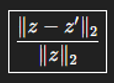

In [5]:
original_files = sorted([f for f in os.listdir(input_original_dir) if f.endswith(".npy")])#[:5]
mirrored_files = sorted([f for f in os.listdir(input_mirrored_dir) if f.endswith(".npy")])#[:5]

means = []
cont = 0

mu_list_original_objects = compute_mu_list(original_files, "vae_original")
max_tensorl2_from_100mu = compute_mean_tensor_from_mu_list(mu_list_original_objects)

print(torch.norm(max_tensorl2_from_100mu[0], dim=-1))

for i in original_files:
    if original_files[cont] == mirrored_files[cont]:
        file_path_original = os.path.join(input_original_dir, i)
        file_path_mirrored = os.path.join(input_mirrored_dir, i)
        
        x_original = np.load(file_path_original)
        x_mirrored = np.load(file_path_mirrored)

    if x_original.ndim == 2 and x_mirrored.ndim == 2: # Matriz
        x_original = x_original[None, ...]
        x_mirrored = x_mirrored[None, ...]
        #print(x.shape)

    x_original_tensor = torch.tensor(x_original, dtype=torch.float32).to(device)
    x_mirrored_tensor = torch.tensor(x_mirrored, dtype=torch.float32).to(device)

    x_latent_list_original = vae_original.get_latents_mu(x_original_tensor)
    x_latent_list_mirrored = vae_original.get_latents_mu(x_mirrored_tensor)
    
    #print(x_latent_list_mirrored[0])

    """ if cont == 3:
        break """

    euclidian_distance_numerator = torch.norm(x_latent_list_original[0] - x_latent_list_mirrored[0], dim=-1)
    #euclidian_distance_denominator = torch.norm(x_latent_list_original[0], dim=-1)
    euclidian_distance_denominator = (0.5 * (torch.norm(x_latent_list_original[0], dim=-1) + torch.norm(x_latent_list_mirrored[0], dim=-1)))

    """ print("1", torch.norm(x_latent_list_original[0], dim=-1))
    print("2", torch.norm(x_latent_list_mirrored[0], dim=-1))
    print("Numerator", euclidian_distance_numerator.item())
    print("Denominator", euclidian_distance_denominator.item()) """

    result = euclidian_distance_numerator / euclidian_distance_denominator
    means.append(result.item())

    cont += 1

print(means)
print("\nAverage mean " + str(cont) +":", statistics.mean(means))
print("Average mean/max:", max(means))
print("Average mean/min:", min(means))

tensor(7.9883, device='cuda:0')
[0.35229796171188354, 0.2738359868526459, 0.24569639563560486, 0.2960525453090668, 0.42767277359962463, 0.2693062424659729, 0.29571670293807983, 0.36779725551605225, 0.311209112405777, 0.33932268619537354, 0.2725246250629425, 0.2717714011669159, 0.36807382106781006, 0.23725780844688416, 0.28246450424194336, 0.2875170111656189, 0.30498963594436646, 0.3230127692222595, 0.34185463190078735, 0.3527408242225647, 0.2184666395187378, 0.24275195598602295, 0.33755922317504883, 0.40464016795158386, 0.32478711009025574, 0.2845357060432434, 0.2842676043510437, 0.30093520879745483, 0.30521222949028015, 0.2603074908256531, 0.34123069047927856, 0.22263719141483307, 0.2274596244096756, 0.4114024043083191, 0.31882408261299133, 0.48203495144844055, 0.33570554852485657, 0.31765779852867126, 0.2742384970188141, 0.25400617718696594, 0.26329702138900757, 0.298745721578598, 0.367764949798584, 0.4128086566925049, 0.37222740054130554, 0.2971210181713104, 0.2607640326023102, 0.41

### Test 2

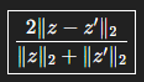

In [6]:
original_files = sorted([f for f in os.listdir(input_original_dir) if f.endswith(".npy")])#[:10]
mirrored_files = sorted([f for f in os.listdir(input_mirrored_dir) if f.endswith(".npy")])#[:10]

per_objects_mean_original = []
per_objects_mean_mirrored = []

means = []
cont = 0

for i in original_files:
    if original_files[cont] == mirrored_files[cont]:
        file_path_original = os.path.join(input_original_dir, i)
        file_path_mirrored = os.path.join(input_mirrored_dir, i)
        
        x_original = np.load(file_path_original)
        x_mirrored = np.load(file_path_mirrored)

    if x_original.ndim == 2 and x_mirrored.ndim == 2: # Matriz
        x_original = x_original[None, ...]
        x_mirrored = x_mirrored[None, ...]
        #print(x.shape)

    x_original_tensor = torch.tensor(x_original, dtype=torch.float32).to(device)
    x_mirrored_tensor = torch.tensor(x_mirrored, dtype=torch.float32).to(device)

    x_latent_list_original = vae_original.get_latents_mu(x_original_tensor)
    x_latent_list_mirrored = vae_original.get_latents_mu(x_mirrored_tensor)
    
    cosine_similarity_numerator = torch.norm(x_latent_list_original[0] - x_latent_list_mirrored[0], dim=-1)
    cosine_similarity_denominator_1 = torch.norm(x_latent_list_original[0], dim=-1)
    cosine_similarity_denominator_2 = torch.norm(x_latent_list_mirrored[0], dim=-1)

    #print("Numerator:", cosine_similarity_numerator.item())
    #print("Denominator (from origin):", cosine_similarity_denominator_1.item())
    #print("Denominator (from origin):", cosine_similarity_denominator_2.item())

    result = (2*cosine_similarity_numerator) / (cosine_similarity_denominator_1 + cosine_similarity_denominator_2)

    means.append(result.mean().item())

    cont += 1

print("\nAverage mean " + str(cont) +":", statistics.mean(means))
print("Average mean/max:", max(means))
print("Average mean/min:", min(means))


Average mean 405: 0.3168420214711884
Average mean/max: 0.5173933506011963
Average mean/min: 0.14279866218566895


## Latents from mirrored encoder

In [7]:
original_files = sorted([f for f in os.listdir(input_original_dir) if f.endswith(".npy")])#[:5]
mirrored_files = sorted([f for f in os.listdir(input_mirrored_dir) if f.endswith(".npy")])#[:5]

x_original_tensor = 0
x_mirrored_tensor = 0

x_latent_list_original = 0
x_latent_list_mirrored = 0

euclidian_distance_numerator = 0
euclidian_distance_denominator = 0

result = 0

means = []
cont = 0

mu_list_original_objects = 0
max_tensorl2_from_100mu = 0

mu_list_original_objects = compute_mu_list(mirrored_files, "vae_mirrored")
max_tensorl2_from_100mu = compute_l2_from_mu_list(mu_list_original_objects)

print(torch.norm(max_tensorl2_from_100mu[0], dim=-1))

for i in original_files:
    if original_files[cont] == mirrored_files[cont]:
        file_path_original = os.path.join(input_original_dir, i)
        file_path_mirrored = os.path.join(input_mirrored_dir, i)
        
        x_original = np.load(file_path_original)
        x_mirrored = np.load(file_path_mirrored)

    if x_original.ndim == 2 and x_mirrored.ndim == 2: # Matriz
        x_original = x_original[None, ...]
        x_mirrored = x_mirrored[None, ...]
        #print(x.shape)

    x_original_tensor = torch.tensor(x_original, dtype=torch.float32).to(device)
    x_mirrored_tensor = torch.tensor(x_mirrored, dtype=torch.float32).to(device)

    x_latent_list_original = vae_mirrored.get_latents_mu(x_original_tensor)
    x_latent_list_mirrored = vae_mirrored.get_latents_mu(x_mirrored_tensor)
    
    #print(x_latent_list_mirrored[0])

    """ if cont == 3:
        break """

    euclidian_distance_numerator = torch.norm(x_latent_list_original[0] - x_latent_list_mirrored[0], dim=-1)
    #euclidian_distance_denominator = torch.norm(x_latent_list_mirrored[0], dim=-1)
    euclidian_distance_denominator = (0.5 * (torch.norm(x_latent_list_original[0], dim=-1) + torch.norm(x_latent_list_mirrored[0], dim=-1)))

    """ print("1", torch.norm(x_latent_list_original[0], dim=-1))
    print("2", torch.norm(x_latent_list_mirrored[0], dim=-1))
    print("Numerator", euclidian_distance_numerator.item())
    print("Denominator", euclidian_distance_denominator.item()) """

    result = euclidian_distance_numerator / euclidian_distance_denominator
    means.append(result.item())

    cont += 1

print(means)
print("\nAverage mean " + str(cont) +":", statistics.mean(means))
print("Average mean/max:", max(means))
print("Average mean/min:", min(means))

tensor(4.7118, device='cuda:0')
[0.799662709236145, 0.7969939708709717, 0.7944563031196594, 0.7623484134674072, 0.7180758714675903, 0.7271340489387512, 0.6405074596405029, 0.8827282190322876, 0.7168421745300293, 0.7834895253181458, 0.6375693678855896, 0.8558538556098938, 0.8629871010780334, 0.7598660588264465, 0.693426251411438, 0.634147047996521, 0.7628200650215149, 0.8444100618362427, 0.8052231669425964, 0.7261412143707275, 0.7703679800033569, 0.8044974207878113, 0.7782298922538757, 0.9252071380615234, 0.6963781714439392, 0.6569206714630127, 0.9316020607948303, 0.940636157989502, 0.7027921080589294, 0.7041557431221008, 0.7745649218559265, 0.7854459285736084, 0.7249401211738586, 0.6178092956542969, 0.8862789273262024, 0.7749248147010803, 0.8891717195510864, 0.8330335021018982, 0.9680637717247009, 0.60457444190979, 0.8311751484870911, 0.7717195153236389, 0.7470094561576843, 0.8161088824272156, 0.8156789541244507, 0.8170335292816162, 0.7277902364730835, 0.9902849793434143, 0.88798910379

### Distancia de Cosenos

Original

In [8]:
original_files = sorted([f for f in os.listdir(input_original_dir) if f.endswith(".npy")])#[:5]
mirrored_files = sorted([f for f in os.listdir(input_mirrored_dir) if f.endswith(".npy")])#[:5]

means = []
cont = 0

mu_list_original_objects = compute_mu_list(original_files, "vae_original")
max_tensorl2_from_100mu = compute_mean_tensor_from_mu_list(mu_list_original_objects)

print(torch.norm(max_tensorl2_from_100mu[0], dim=-1))

for i in original_files:
    if original_files[cont] == mirrored_files[cont]:
        file_path_original = os.path.join(input_original_dir, i)
        file_path_mirrored = os.path.join(input_mirrored_dir, i)
        
        x_original = np.load(file_path_original)
        x_mirrored = np.load(file_path_mirrored)

    if x_original.ndim == 2 and x_mirrored.ndim == 2: # Matriz
        x_original = x_original[None, ...]
        x_mirrored = x_mirrored[None, ...]
        #print(x.shape)

    x_original_tensor = torch.tensor(x_original, dtype=torch.float32).to(device)
    x_mirrored_tensor = torch.tensor(x_mirrored, dtype=torch.float32).to(device)

    x_latent_list_original = vae_original.get_latents_mu(x_original_tensor)
    x_latent_list_mirrored = vae_original.get_latents_mu(x_mirrored_tensor)
    
    #print(x_latent_list_mirrored[0])

    """ if cont == 3:
        break """

    euclidian_distance_numerator = torch.norm(x_latent_list_original[0] - x_latent_list_mirrored[0], dim=-1)
    #euclidian_distance_denominator = torch.norm(x_latent_list_original[0], dim=-1)
    euclidian_distance_denominator = (0.5 * (torch.norm(x_latent_list_original[0], dim=-1) + torch.norm(x_latent_list_mirrored[0], dim=-1)))

    """ print("1", torch.norm(x_latent_list_original[0], dim=-1))
    print("2", torch.norm(x_latent_list_mirrored[0], dim=-1))
    print("Numerator", euclidian_distance_numerator.item())
    print("Denominator", euclidian_distance_denominator.item()) """

    result = 1.0 - torch.nn.functional.cosine_similarity(x_latent_list_original[0][0], x_latent_list_mirrored[0][0], dim=-1)
    means.append(result.item())

    cont += 1

print(means)
print("\nAverage mean " + str(cont) +":", f"{statistics.mean(means):.12f}")
print("Average mean/max:", max(means))
print("Average mean/min:", min(means))

tensor(7.9883, device='cuda:0')
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, -1.1920928955078125e-07, 0.0, 0.0, 5.960464477539063e-08, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 1.1920928955078125e-07, -1.1920928955078125e-07, 0.0, 0.0, 5.960464477539063e-08, 0.0, -1.1920928955078125e-07, -1.1920928955078125e-07, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 5.960464477539063e-08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.960464477539063e-08, 0.0, 0.0, 0.0, 0.0, 1.1920928955078125e-07, 5.960464477539063e-08, 0.0, 0.0, 0.0, 1.1920928955078125e-07, -1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e

Mirrored

In [9]:
original_files = sorted([f for f in os.listdir(input_original_dir) if f.endswith(".npy")])#[:5]
mirrored_files = sorted([f for f in os.listdir(input_mirrored_dir) if f.endswith(".npy")])#[:5]

x_original_tensor = 0
x_mirrored_tensor = 0

x_latent_list_original = 0
x_latent_list_mirrored = 0

euclidian_distance_numerator = 0
euclidian_distance_denominator = 0

result = 0

means = []
cont = 0

mu_list_original_objects = 0
max_tensorl2_from_100mu = 0

mu_list_original_objects = compute_mu_list(mirrored_files, "vae_mirrored")
max_tensorl2_from_100mu = compute_l2_from_mu_list(mu_list_original_objects)

print(torch.norm(max_tensorl2_from_100mu[0], dim=-1))

for i in original_files:
    if original_files[cont] == mirrored_files[cont]:
        file_path_original = os.path.join(input_original_dir, i)
        file_path_mirrored = os.path.join(input_mirrored_dir, i)
        
        x_original = np.load(file_path_original)
        x_mirrored = np.load(file_path_mirrored)

    if x_original.ndim == 2 and x_mirrored.ndim == 2: # Matriz
        x_original = x_original[None, ...]
        x_mirrored = x_mirrored[None, ...]
        #print(x.shape)

    x_original_tensor = torch.tensor(x_original, dtype=torch.float32).to(device)
    x_mirrored_tensor = torch.tensor(x_mirrored, dtype=torch.float32).to(device)

    x_latent_list_original = vae_mirrored.get_latents_mu(x_original_tensor)
    x_latent_list_mirrored = vae_mirrored.get_latents_mu(x_mirrored_tensor)
    
    #print(x_latent_list_mirrored[0])

    """ if cont == 3:
        break """

    euclidian_distance_numerator = torch.norm(x_latent_list_original[0] - x_latent_list_mirrored[0], dim=-1)
    #euclidian_distance_denominator = torch.norm(x_latent_list_mirrored[0], dim=-1)
    euclidian_distance_denominator = (0.5 * (torch.norm(x_latent_list_original[0], dim=-1) + torch.norm(x_latent_list_mirrored[0], dim=-1)))

    """ print("1", torch.norm(x_latent_list_original[0], dim=-1))
    print("2", torch.norm(x_latent_list_mirrored[0], dim=-1))
    print("Numerator", euclidian_distance_numerator.item())
    print("Denominator", euclidian_distance_denominator.item()) """

    result = 1.0 - torch.nn.functional.cosine_similarity(x_latent_list_original[0][0], x_latent_list_mirrored[0][0], dim=-1)
    means.append(result.item())

    cont += 1

print(means)
print("\nAverage mean " + str(cont) +":", f"{statistics.mean(means):.12f}")
print("Average mean/max:", max(means))
print("Average mean/min:", min(means))

tensor(4.7117, device='cuda:0')
[0.0, 0.0, 0.0, 0.0, 1.1920928955078125e-07, 1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.960464477539063e-08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 1.1920928955078125e-07, 0.0, 0.0, -1.1920928955078125e-07, 0.0, -1.1920928955078125e-07, 0.0, 5.960464477539063e-08, 0.0, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 5.960464477539063e-08, 5.960464477539063e-08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.960464477539063e-08, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 0.0, 0.0, 0.0, 0.0, 5.960464477539063e-08, -1.1920928955078125e-07, 0.0, 0.0, 5.960464477539063e-08, 0.0, 0.0, 5.960464477539063e-08, 0.0, 0.0, 0.0, 0.0, -1.1920928955078125e-07, 0.0, 5.960464477539063e-08, 0.0, 0.0, 0.0, 0.0, 5.960464477539063e-08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.960464477539063e-08, -1.1920928955078125e-07, 5.960464477539063e-08, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.192092

In [10]:
""" # Obtain h_0
with torch.no_grad():
    h0 = vae.get_latent_points(x_tensor)

np.save(ouput_path, h0.squeeze(0).cpu().numpy())
print("done") """

' # Obtain h_0\nwith torch.no_grad():\n    h0 = vae.get_latent_points(x_tensor)\n\nnp.save(ouput_path, h0.squeeze(0).cpu().numpy())\nprint("done") '